****Part 1: PROJECT INTRODUCTION AND SETUP****

In [1]:
# Library Imports
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
import shutil
from tqdm import tqdm
from lime import lime_image
from skimage.segmentation import mark_boundaries

2025-10-22 13:42:06.011468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761140526.186967      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761140526.247297      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


****PART 2: DATA PREPARATION AND LOADING****

In [2]:
# Configuration Parameters
DATA_DIR = "/kaggle/input/cactus-final/Cactus_final"
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 75
CHANNELS = 3
CLASS_NAMES = ['Affected', 'Healthy', 'No cactus']
K_FOLDS = 3

# Loading Data for K-Fold Cross-Validation
images = []
labels = []
class_to_label = {name: i for i, name in enumerate(CLASS_NAMES)}

for class_name, label_index in class_to_label.items():
    class_path = os.path.join(DATA_DIR, class_name)  # Replace temp_data_dir with DATA_DIR here
    for img_file in tqdm(os.listdir(class_path), desc=f"Loading {class_name} images"):
        img_path = os.path.join(class_path, img_file)
        img = image.load_img(img_path, target_size=IMAGE_SIZE)
        img_array = image.img_to_array(img) / 255.0
        images.append(img_array)
        labels.append(label_index)

X = np.array(images)
y = np.array(labels)
print(f"Dataset loaded: {X.shape[0]} images found.")

Loading No cactus images: 100%|██████████| 587/587 [00:05<00:00, 98.77it/s]


Dataset loaded: 3587 images found.


Data Augumentation

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation (4 techniques: rotation, zoom, shift, flip)
datagen = ImageDataGenerator(
    rotation_range=20,      # Random rotation (±20°)
    zoom_range=0.15,        # Random zoom (85-115%)
    width_shift_range=0.2,  # Random horizontal shift (±20%)
    height_shift_range=0.2, # Random vertical shift (±20%)
    horizontal_flip=True,   # Random horizontal flip
    fill_mode='nearest'     # Fill gaps with nearest pixels
)

# Apply augmentation to training data
augmented_train = datagen.flow(X, y, batch_size=BATCH_SIZE)

****PART 3: MODEL DEFINITION & SETUP****

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os# Defining checkpoint path (same as original save path)
checkpoint_path = "best_cactus_model_kfold.keras"

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# A function to create a new, fresh model for each fold.
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize K-Fold and variables
kfold = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_accuracies = []
fold_histories = []
best_model = None
best_accuracy = 0.0
best_fold_history = None
fold = 1

print("Model setup complete. Ready for training...")

Model setup complete. Ready for training...


****PART 4: TRAINING LOOP****



--- Training Fold 1/3 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761140587.616924      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Starting fresh training for fold 1...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75


I0000 00:00:1761140592.073409      61 service.cc:148] XLA service 0x797320005880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761140592.074297      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761140592.349909      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/113 ━━━━━━━━━━━━━━━━━━━━ 13:50 7s/step - accuracy: 0.2500 - loss: 1.3828

I0000 00:00:1761140596.955828      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.4856 - loss: 1.2002
Epoch 1: val_accuracy improved from -inf to 0.65468, saving model to best_cactus_model_kfold.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 57s 438ms/step - accuracy: 0.4863 - loss: 1.1991 - val_accuracy: 0.6547 - val_loss: 0.9223
Epoch 2/75
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.6560 - loss: 0.8942
Epoch 2: val_accuracy improved from 0.65468 to 0.73328, saving model to best_cactus_model_kfold.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 44s 390ms/step - accuracy: 0.6561 - loss: 0.8940 - val_accuracy: 0.7333 - val_loss: 0.7432
Epoch 3/75
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.6877 - loss: 0.8072
Epoch 3: val_accuracy improved from 0.73328 to 0.77090, saving model to best_cactus_model_kfold.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 44s 388ms/step - accuracy: 0.6877 - loss: 0.8071 - val_accuracy: 0.7709 - val_loss: 0.6726
Epoch 4/75
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6975 - loss: 0.7

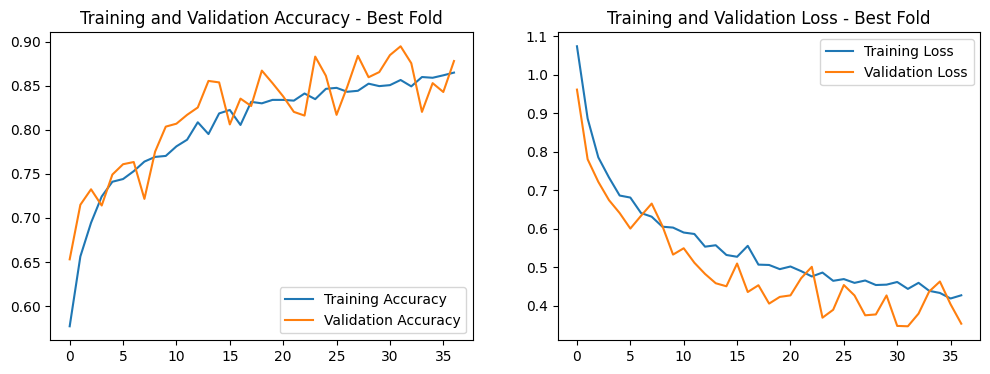

In [5]:
# Fix: Initialize initial_epoch outside the loop
initial_epoch = 0

for train_index, val_index in kfold.split(X, y):
    print(f"\n--- Training Fold {fold}/{K_FOLDS} ---")
    
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]
    
    # Load or create model
    if os.path.exists(checkpoint_path) and fold == 1:
        model = tf.keras.models.load_model(checkpoint_path)
        print(f"Resuming training for fold {fold} from saved model...")
        # Get last epoch from previous training if history exists
        if 'history' in globals() and hasattr(history, 'history'):
            initial_epoch = len(history.history['val_accuracy'])
        else:
            initial_epoch = 0
    else:
        model = create_model()
        initial_epoch = 0
        print(f"Starting fresh training for fold {fold}...")
    
    history = model.fit(
        augmented_train if 'augmented_train' in locals() else X_train,  # Handles both augmented/normal data
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1,
        initial_epoch=initial_epoch
    )

    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold} - Validation Accuracy: {accuracy:.4f}")
    
    fold_accuracies.append(accuracy)
    fold_histories.append(history)

    # Save the best model from all folds
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_fold_history = history
        best_model.save('best_cactus_model_kfold.keras')
        print("Model saved as the best-performing model so far.")
        
    fold += 1

print(f"\n--- Cross-Validation Results ---\n")
print(f"Average Validation Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})\n")

# Visualization of Training History for the Best Fold
def plot_best_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy - Best Fold')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss - Best Fold')
    plt.show()

# Plot the history for the best fold
if best_fold_history:
    plot_best_history(best_fold_history)
else:
    print("No model was saved. Please check your training loop.")

******PART 4: EVALUATION AND MODEL EXPLAINABILITY******


--- Final Model Evaluation on Test Set ---
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


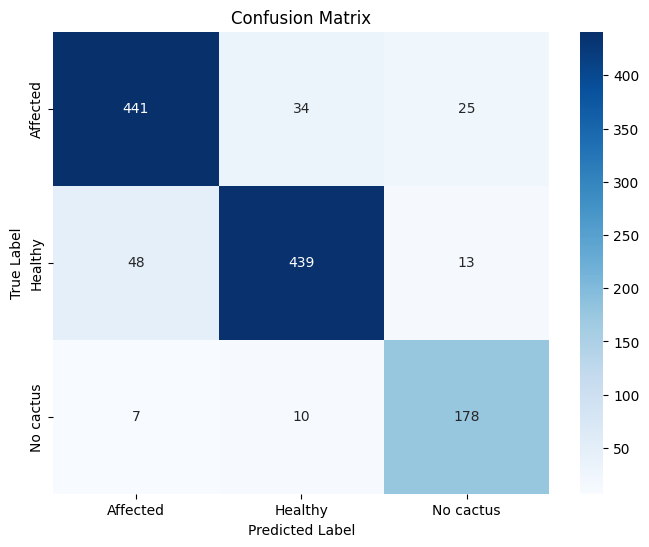


Classification Report:
               precision    recall  f1-score   support

    Affected       0.89      0.88      0.89       500
     Healthy       0.91      0.88      0.89       500
   No cactus       0.82      0.91      0.87       195

    accuracy                           0.89      1195
   macro avg       0.87      0.89      0.88      1195
weighted avg       0.89      0.89      0.89      1195



In [6]:
# PART 4: FINAL EVALUATION
# Final Model Evaluation on the Last Fold
print("\n--- Final Model Evaluation on Test Set ---")
_, test_index = list(kfold.split(X, y))[-1] 
X_test, y_test = X[test_index], y[test_index]

# Load the best model from the training process
best_model = tf.keras.models.load_model('best_cactus_model_kfold.keras')

# Run predictions on the test data.
predictions = best_model.predict(X_test)
y_pred_classes = np.argmax(predictions, axis=1)

# Confusion Matrix and Classification Report
conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES))

******PART-5 LIME EXPLAINABILITY FOR IMAGE CLASSIFICATION (Keras)******


Best model loaded successfully!
Overall Test Accuracy: 0.8821
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


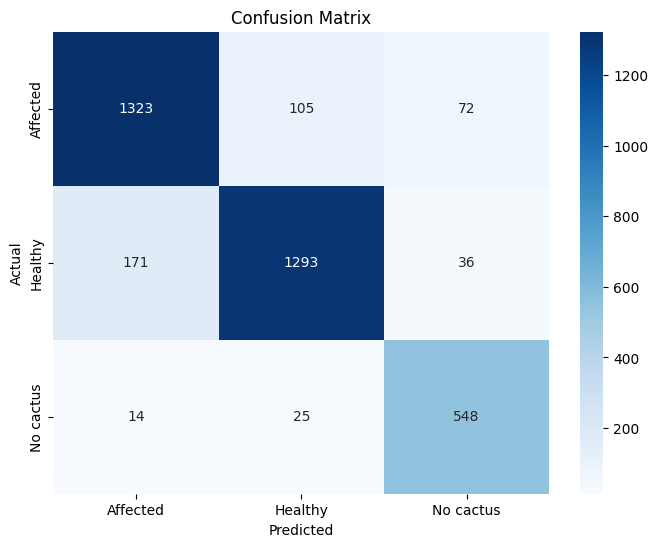


Classification Report:
              precision    recall  f1-score   support

    Affected       0.88      0.88      0.88      1500
     Healthy       0.91      0.86      0.88      1500
   No cactus       0.84      0.93      0.88       587

    accuracy                           0.88      3587
   macro avg       0.87      0.89      0.88      3587
weighted avg       0.88      0.88      0.88      3587


Generating LIME explanations for sample images...

--- Affected Class ---
Sample 1:
  Actual: Affected, Predicted: Affected, Confidence: 0.9152


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

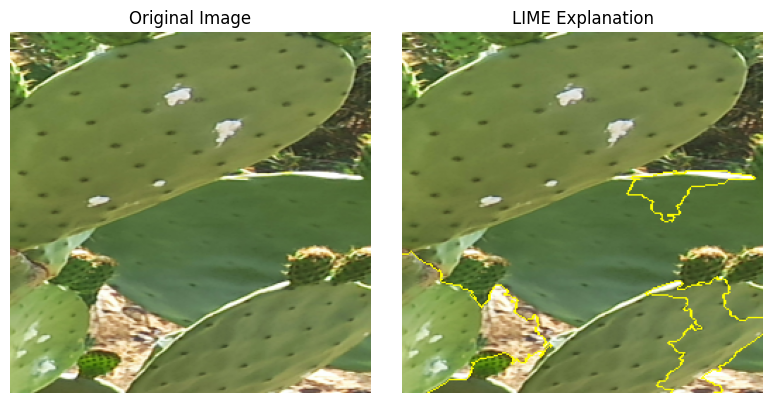

Sample 2:
  Actual: Affected, Predicted: Affected, Confidence: 0.8413


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

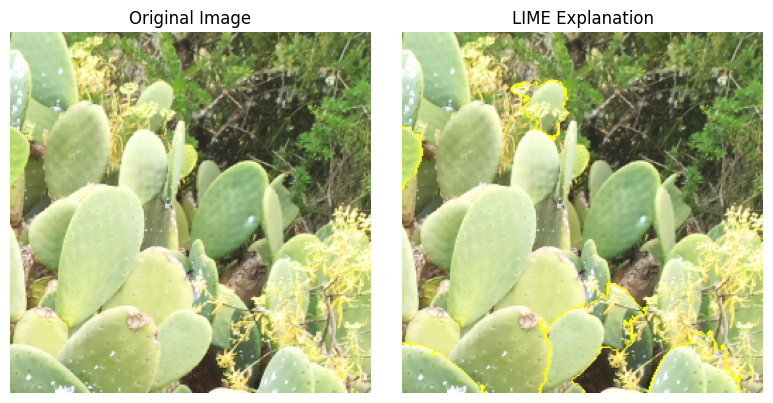


--- Healthy Class ---
Sample 1:
  Actual: Healthy, Predicted: Healthy, Confidence: 0.9624


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

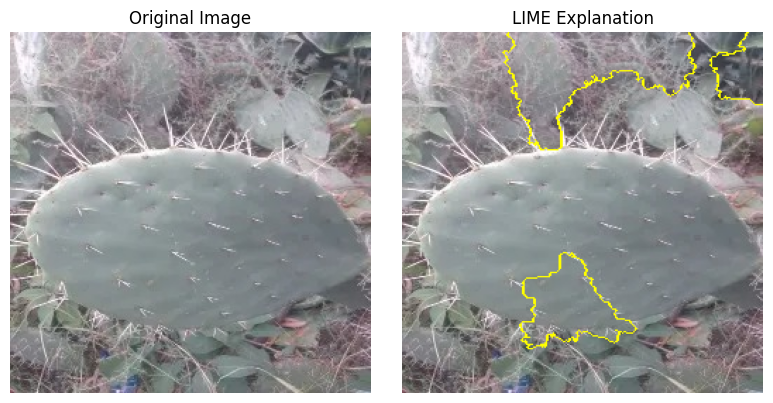

Sample 2:
  Actual: Healthy, Predicted: Healthy, Confidence: 0.9871


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

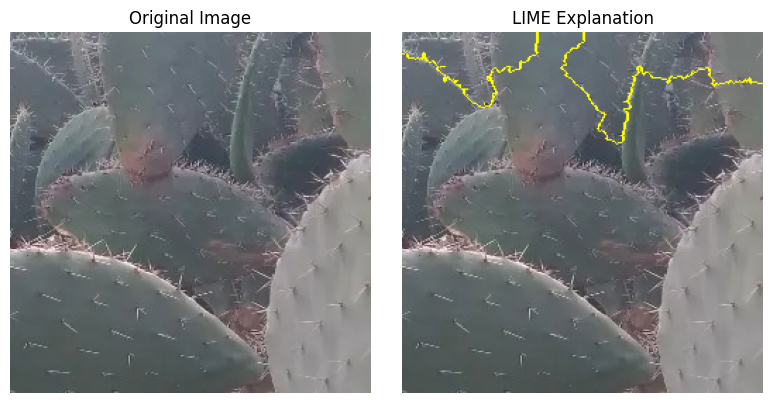


--- No cactus Class ---
Sample 1:
  Actual: No cactus, Predicted: No cactus, Confidence: 0.9447


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

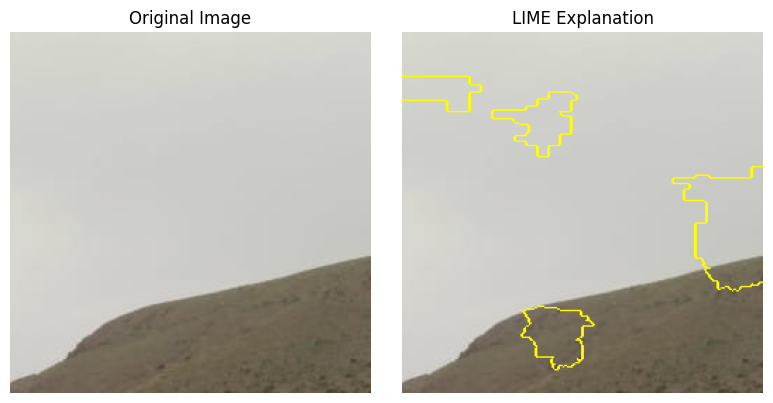

Sample 2:
  Actual: No cactus, Predicted: No cactus, Confidence: 0.9888


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

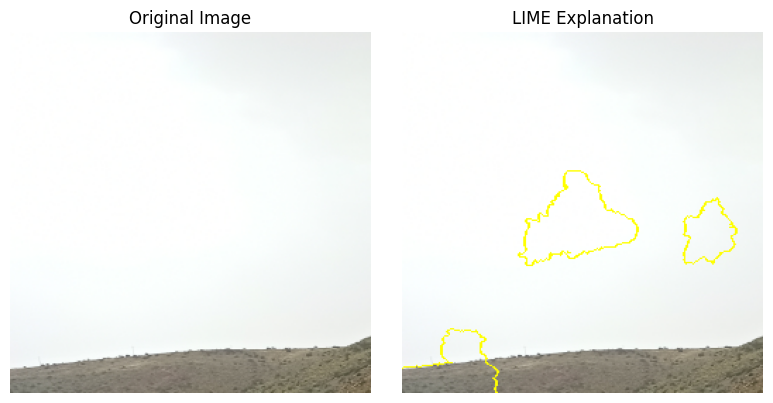


--- Model Evaluation Complete ---


In [7]:
# ****PART 5: MODEL EVALUATION AND EXPLANATION****

# Load the best model for evaluation
best_model = tf.keras.models.load_model('best_cactus_model_kfold.keras')
print("Best model loaded successfully!")

# Evaluate on the entire dataset
test_loss, test_accuracy = best_model.evaluate(X, y, verbose=0)
print(f"Overall Test Accuracy: {test_accuracy:.4f}")

# Predictions for confusion matrix
y_pred = best_model.predict(X)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y, y_pred_classes, target_names=CLASS_NAMES))

# LIME Explanation (Optional - only if you want to use it)
def lime_explanation(model, image_array, class_names):
    """
    Generate LIME explanation for a single image
    """
    def model_predict(images):
        # LIME uses RGB images in [0,1] range
        return model.predict(images)
    
    # Create LIME explainer
    explainer = lime_image.LimeImageExplainer()
    
    # Explain the image
    explanation = explainer.explain_instance(
        image_array.astype('double'), 
        model_predict, 
        top_labels=3, 
        hide_color=0, 
        num_samples=1000
    )
    
    # Get explanation for the top class
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    
    # Plot the explanation
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image_array)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title('LIME Explanation')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return explanation

# Test LIME on a few sample images
print("\nGenerating LIME explanations for sample images...")

# Select a few random images from each class for explanation
num_samples_per_class = 2
for class_idx, class_name in enumerate(CLASS_NAMES):
    print(f"\n--- {class_name} Class ---")
    class_indices = np.where(y == class_idx)[0]
    sample_indices = np.random.choice(class_indices, num_samples_per_class, replace=False)
    
    for i, idx in enumerate(sample_indices):
        print(f"Sample {i+1}:")
        actual_class = CLASS_NAMES[y[idx]]
        predicted_class = CLASS_NAMES[y_pred_classes[idx]]
        confidence = y_pred[idx][y_pred_classes[idx]]
        
        print(f"  Actual: {actual_class}, Predicted: {predicted_class}, Confidence: {confidence:.4f}")
        
        # Generate LIME explanation
        try:
            explanation = lime_explanation(best_model, X[idx], CLASS_NAMES)
        except Exception as e:
            print(f"  LIME explanation failed: {e}")
            continue

print("\n--- Model Evaluation Complete ---")